In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pyreadstat
import pickle

In [86]:
_, meta_22_23 = pyreadstat.read_sav("active_lives_survey_nov_22-23_data_year_8_shared_20250103.sav", row_limit=1)

overall_df = pd.read_csv("2016_to_2023_full_preprocessed_data_set.csv")

In [87]:
overall_df["VolAny"] = overall_df["VolAny"].fillna(0)

In [88]:
motivation_cols = ["Motiva_POP", "motivb_POP", "motivc_POP"]

motivation_df = overall_df[motivation_cols].dropna().copy()

scaler = StandardScaler()
motivation_scaled = scaler.fit_transform(motivation_df)

pca = PCA(n_components=1)
pc1 = pca.fit_transform(motivation_scaled).flatten()

print(f"PC1 explains {pca.explained_variance_ratio_[0]:.3f} of the variance")

motivation_df["Motivation_PC"] = pc1

overall_df = overall_df.merge(motivation_df[["Motivation_PC"]], left_index=True, right_index=True, how="left")

PC1 explains 0.666 of the variance


In [89]:
input_cols = ["Age9",
              "Gend3",
              "Eth7",
              "Disab3",
              "NSSEC5",
              "Educ6",
              "Child4",
              "IMD10",
              "WorkStat5",
              "VolAny",
              "Motivation_PC"]
  
cluster_df = overall_df[input_cols + ["year"]].dropna().copy()

cluster_df["Motivation_PC_Q"] = (pd.qcut(cluster_df["Motivation_PC"], q=5, labels=False).astype(int))

cluster_df = cluster_df.drop(columns="Motivation_PC")

In [90]:
cluster_cols = ["Age9",
                "Gend3",
                "Eth7",
                "Disab3",
                "NSSEC5",
                "Educ6",
                "Child4",
                "IMD10",
                "WorkStat5",
                "VolAny",
                "Motivation_PC_Q"]

for col in cluster_cols:
    print(cluster_df[col].value_counts(dropna=False))

Age9
4.0    19999
3.0    18402
5.0    16143
6.0    13887
7.0    10762
2.0     7485
8.0      537
9.0      139
Name: count, dtype: int64
Gend3
2.0    48776
1.0    38390
3.0      188
Name: count, dtype: int64
Eth7
1.0    46463
2.0    15340
3.0    12392
4.0     5583
6.0     3075
7.0     2456
5.0     2045
Name: count, dtype: int64
Disab3
3.0    63776
2.0    12961
1.0    10617
Name: count, dtype: int64
NSSEC5
1.0    57604
2.0    15588
3.0     7339
4.0     6147
5.0      676
Name: count, dtype: int64
Educ6
1.0    61300
2.0     9705
3.0     9305
6.0     3275
5.0     2709
4.0     1060
Name: count, dtype: int64
Child4
1.0    60325
2.0    12962
3.0    10878
4.0     3189
Name: count, dtype: int64
IMD10
2.0     13952
3.0     12916
4.0     10877
5.0      9705
6.0      8852
7.0      7511
9.0      7211
8.0      6877
1.0      5602
10.0     3851
Name: count, dtype: int64
WorkStat5
1.0    59955
3.0    16291
4.0     4993
2.0     3706
5.0     2409
Name: count, dtype: int64
VolAny
0.0    75559
1.0    11795
N

In [91]:
for col in cluster_cols:
    cluster_df[col] = cluster_df[col].astype(int)

In [92]:
original_codes = {col: np.sort(cluster_df[col].dropna().unique()) for col in cluster_cols}

X = cluster_df[cluster_cols].copy()

for col in X.columns:
    X[col] -= X[col].min()

for col in cluster_cols:
    cluster_df[col] -= cluster_df[col].min()

n_categories = [cluster_df[col].nunique() for col in cluster_cols]

In [93]:
n_classes = 19

with open(f"stepmix_new_{n_classes}.pkl", "rb") as f:
    model = pickle.load(f)

In [94]:
print(f"\n{n_classes} classes")

measurement = model.get_parameters()["measurement"]
pis = measurement["pis"]

n_classes = pis.shape[0]

assert n_classes == 19

block_size = measurement["max_n_outcomes"]

posterior = model.predict_proba(X)
class_sizes = posterior.mean(axis=0)    

summary_rows = []

for cls in range(n_classes):

    row = {"Class": cls, "Size": f"{class_sizes[cls]:.1%}"}

    for i, (var, ncat) in enumerate(zip(cluster_cols, n_categories)):

        start = i * block_size

        probs = pis[cls, start:start + block_size][:ncat]

        top = np.argsort(probs)[::-1][:3]

        entries = []

        label_dict = meta_22_23.variable_value_labels.get(var, {})

        for idx in top:

            code = original_codes[var][idx]

            label = label_dict.get(code, code) # type: ignore

            entries.append(f"{label} ({probs[idx]:.0%})")

        row[var] = ", ".join(entries)

    summary_rows.append(row)

class_summary = pd.DataFrame(summary_rows)

print(class_summary)

class_summary.to_csv(f"stepmix_{n_classes}_class_summary.csv", index=False)


19 classes
    Class   Size                                   Age9  \
0       0   3.4%  16-24 (25%), 55-64 (22%), 45-54 (22%)   
1       1   2.0%   16-24 (55%), 25-34 (33%), 35-44 (8%)   
2       2   5.4%  35-44 (66%), 45-54 (19%), 25-34 (13%)   
3       3   0.8%     75-84 (79%), 85+ (21%), 65-74 (0%)   
4       4   4.5%   55-64 (58%), 45-54 (33%), 16-24 (4%)   
5       5   3.2%  35-44 (38%), 45-54 (28%), 25-34 (26%)   
6       6   6.6%   45-54 (53%), 35-44 (41%), 55-64 (5%)   
7       7  11.9%  55-64 (50%), 45-54 (28%), 65-74 (11%)   
8       8   4.4%   65-74 (80%), 55-64 (19%), 45-54 (1%)   
9       9   3.6%    16-24 (99%), 25-34 (1%), 35-44 (0%)   
10     10   2.7%  45-54 (31%), 55-64 (29%), 35-44 (16%)   
11     11   2.8%  45-54 (29%), 35-44 (25%), 25-34 (24%)   
12     12   2.3%   35-44 (49%), 25-34 (36%), 45-54 (9%)   
13     13   9.6%   65-74 (67%), 55-64 (30%), 45-54 (2%)   
14     14   3.9%  35-44 (41%), 45-54 (28%), 25-34 (17%)   
15     15   1.9%  55-64 (32%), 65-74 (28%), 

In [95]:
cluster_df["Class"] = model.predict(X)

overall_df = overall_df.copy()

overall_df.loc[cluster_df.index, "Class"] = cluster_df["Class"]

mems_summary = (overall_df.dropna(subset=["MEMS7_ALL", "Class"]).groupby(["Class", "year"]).agg(Mean_MEMS7=("MEMS7_ALL", "mean"), Median_MEMS7=("MEMS7_ALL", "median"), SD_MEMS7=("MEMS7_ALL", "std"), N=("MEMS7_ALL", "size")).reset_index())

class_probabilities = pis.reshape(n_classes, len(cluster_cols), block_size)

In [96]:
dominance_rows = []

for cls in range(n_classes):

    row = {"Class": cls, "Size": round(class_sizes[cls], 3)}

    for i, (var, ncat) in enumerate(zip(cluster_cols, n_categories)):

        probs = class_probabilities[cls, i, :ncat]

        row[var] = probs.max()

    dominance_rows.append(row)

dominance = pd.DataFrame(dominance_rows)

print(dominance.round(2))

    Class  Size  Age9  Gend3  Eth7  Disab3  NSSEC5  Educ6  Child4  IMD10  \
0       0  0.03  0.25   0.51  0.41    0.56    0.76   0.44    0.78   0.24   
1       1  0.02  0.55   0.65  0.31    0.77    0.96   0.91    0.83   0.19   
2       2  0.05  0.66   0.89  0.41    0.90    0.91   0.97    0.42   0.15   
3       3  0.01  0.79   0.52  0.81    0.37    1.00   0.44    0.99   0.14   
4       4  0.04  0.58   0.57  0.76    0.74    0.53   0.45    0.93   0.16   
5       5  0.03  0.38   0.59  0.79    0.80    0.53   0.55    0.41   0.16   
6       6  0.07  0.53   0.57  0.68    0.81    0.89   0.92    0.48   0.16   
7       7  0.12  0.50   0.50  0.74    0.72    0.85   0.88    0.96   0.13   
8       8  0.04  0.80   0.54  0.78    0.59    0.57   0.29    0.98   0.12   
9       9  0.04  0.99   0.56  0.31    0.83    0.96   0.45    0.53   0.20   
10     10  0.03  0.31   0.73  0.58    0.78    0.75   0.74    0.87   0.21   
11     11  0.03  0.29   0.73  0.81    0.83    0.73   0.82    0.59   0.38   
12     12  0

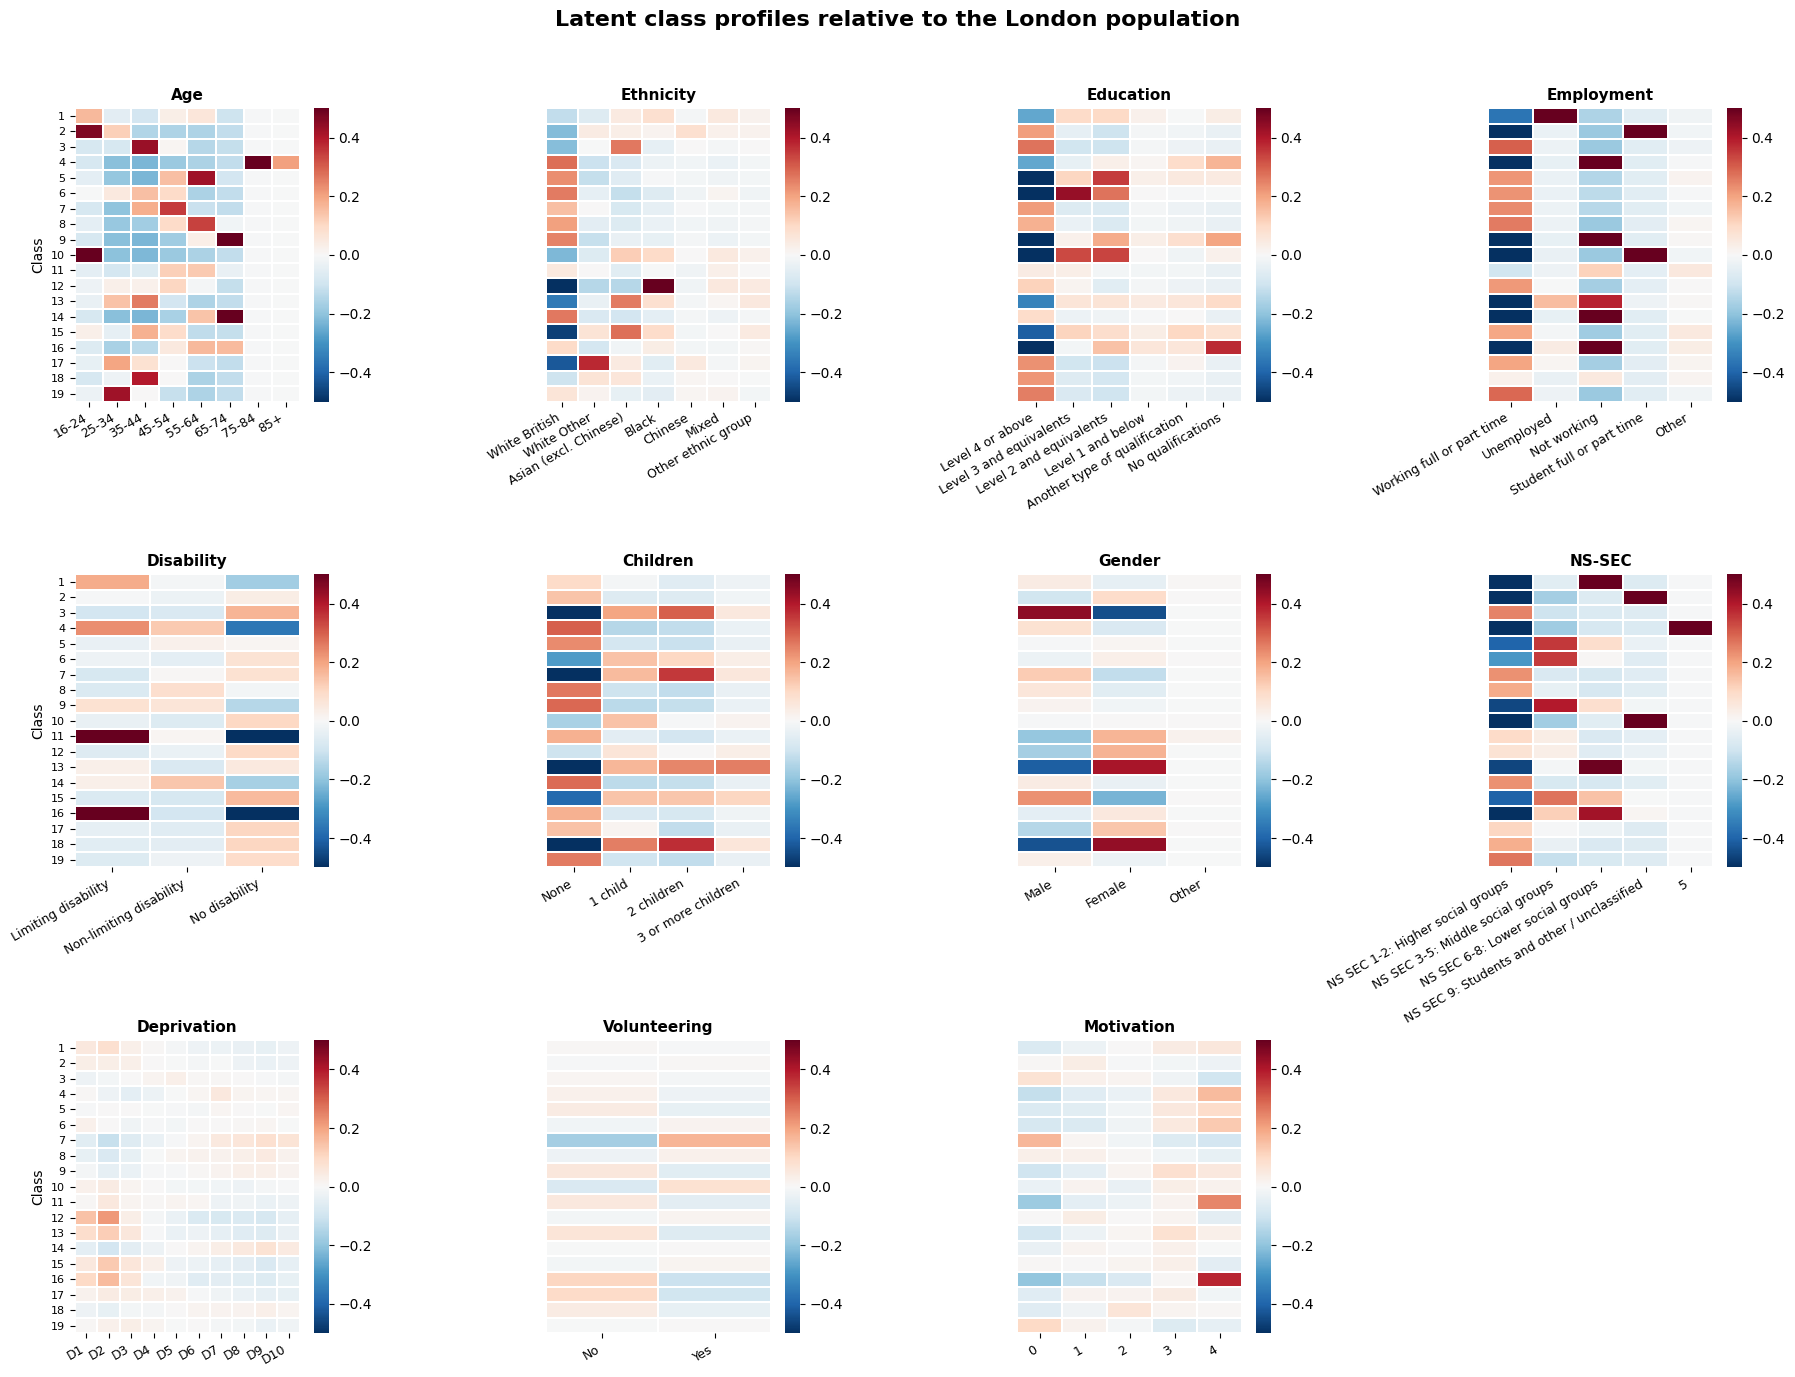

In [97]:
better_names = {"Age9": "Age",
                "Eth7": "Ethnicity",
                "Educ6": "Education",
                "WorkStat5": "Employment",
                "Disab3": "Disability",
                "Child4": "Children",
                "Gend3": "Gender",
                "NSSEC5": "NS-SEC",
                "IMD10": "Deprivation",
                "VolAny": "Volunteering",
                "Motivation_PC_Q": "Motivation"}

plot_order = ["Age9",
              "Eth7",
              "Educ6",
              "WorkStat5",
              "Disab3",
              "Child4",
              "Gend3",
              "NSSEC5",
              "IMD10",
              "VolAny",
              "Motivation_PC_Q"]

fig, axes = plt.subplots(3, 4, figsize=(18, 14))

axes = axes.flatten()

for ax, var in zip(axes, plot_order):

    i = cluster_cols.index(var)
    ncat = n_categories[i]

    population = (cluster_df[var].value_counts(normalize=True).sort_index().values)

    heat = class_probabilities[:, i, :ncat] - population

    codes = original_codes[var]
    label_dict = meta_22_23.variable_value_labels.get(var, {})

    labels = [label_dict.get(code, str(code)) for code in codes]

    if var == "IMD10":
        labels = [f"D{i+1}" for i in range(len(labels))]

    sns.heatmap(heat,
                ax=ax,
                cmap="RdBu_r",
                center=0,
                vmin=-0.5,
                vmax=0.5,
                linewidths=0.3,
                linecolor="white",
                xticklabels=labels,
                yticklabels=False)

    ax.set_title(better_names[var], fontsize=11, fontweight="bold")

    if ax in [axes[0], axes[4], axes[8]]:
        ax.set_yticks(np.arange(n_classes) + 0.5)
        ax.set_yticklabels(range(1, n_classes + 1), fontsize=8)
        ax.set_ylabel("Class")
    else:
        ax.set_yticks([])

    ax.tick_params(axis="x", labelsize=9, rotation=30)

    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

axes[-1].axis("off")

plt.suptitle("Latent class profiles relative to the London population", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96]) # type: ignore

plt.show()

In [98]:
class_names = {0: "Economically disadvantaged\nunemployed adults",
               1: "Highly educated\nuniversity students",
               2: "Established\nprofessional fathers",
               3: "Very elderly\nretired adults",
               4: "Older working\nmiddle-class adults",
               5: "Working-age\nfamilies",
               6: "Affluent\nmid-life families",
               7: "Affluent older\nprofessionals",
               8: "Retired lower-middle\nolder adults",
               9: "Ethnically diverse\nyounger students",
               10: "Working adults with\nlimiting disability",
               11: "Black working\nprofessionals",
               12: "Asian women\nwith families",
               13: "Healthy retired\nprofessionals",
               14: "Asian working\nfamilies",
               15: "Highly disadvantaged\ndisabled older adults",
               16: "Young professional\nwomen",
               17: "Professional\nmothers",
               18: "Mainstream young\nprofessionals",}

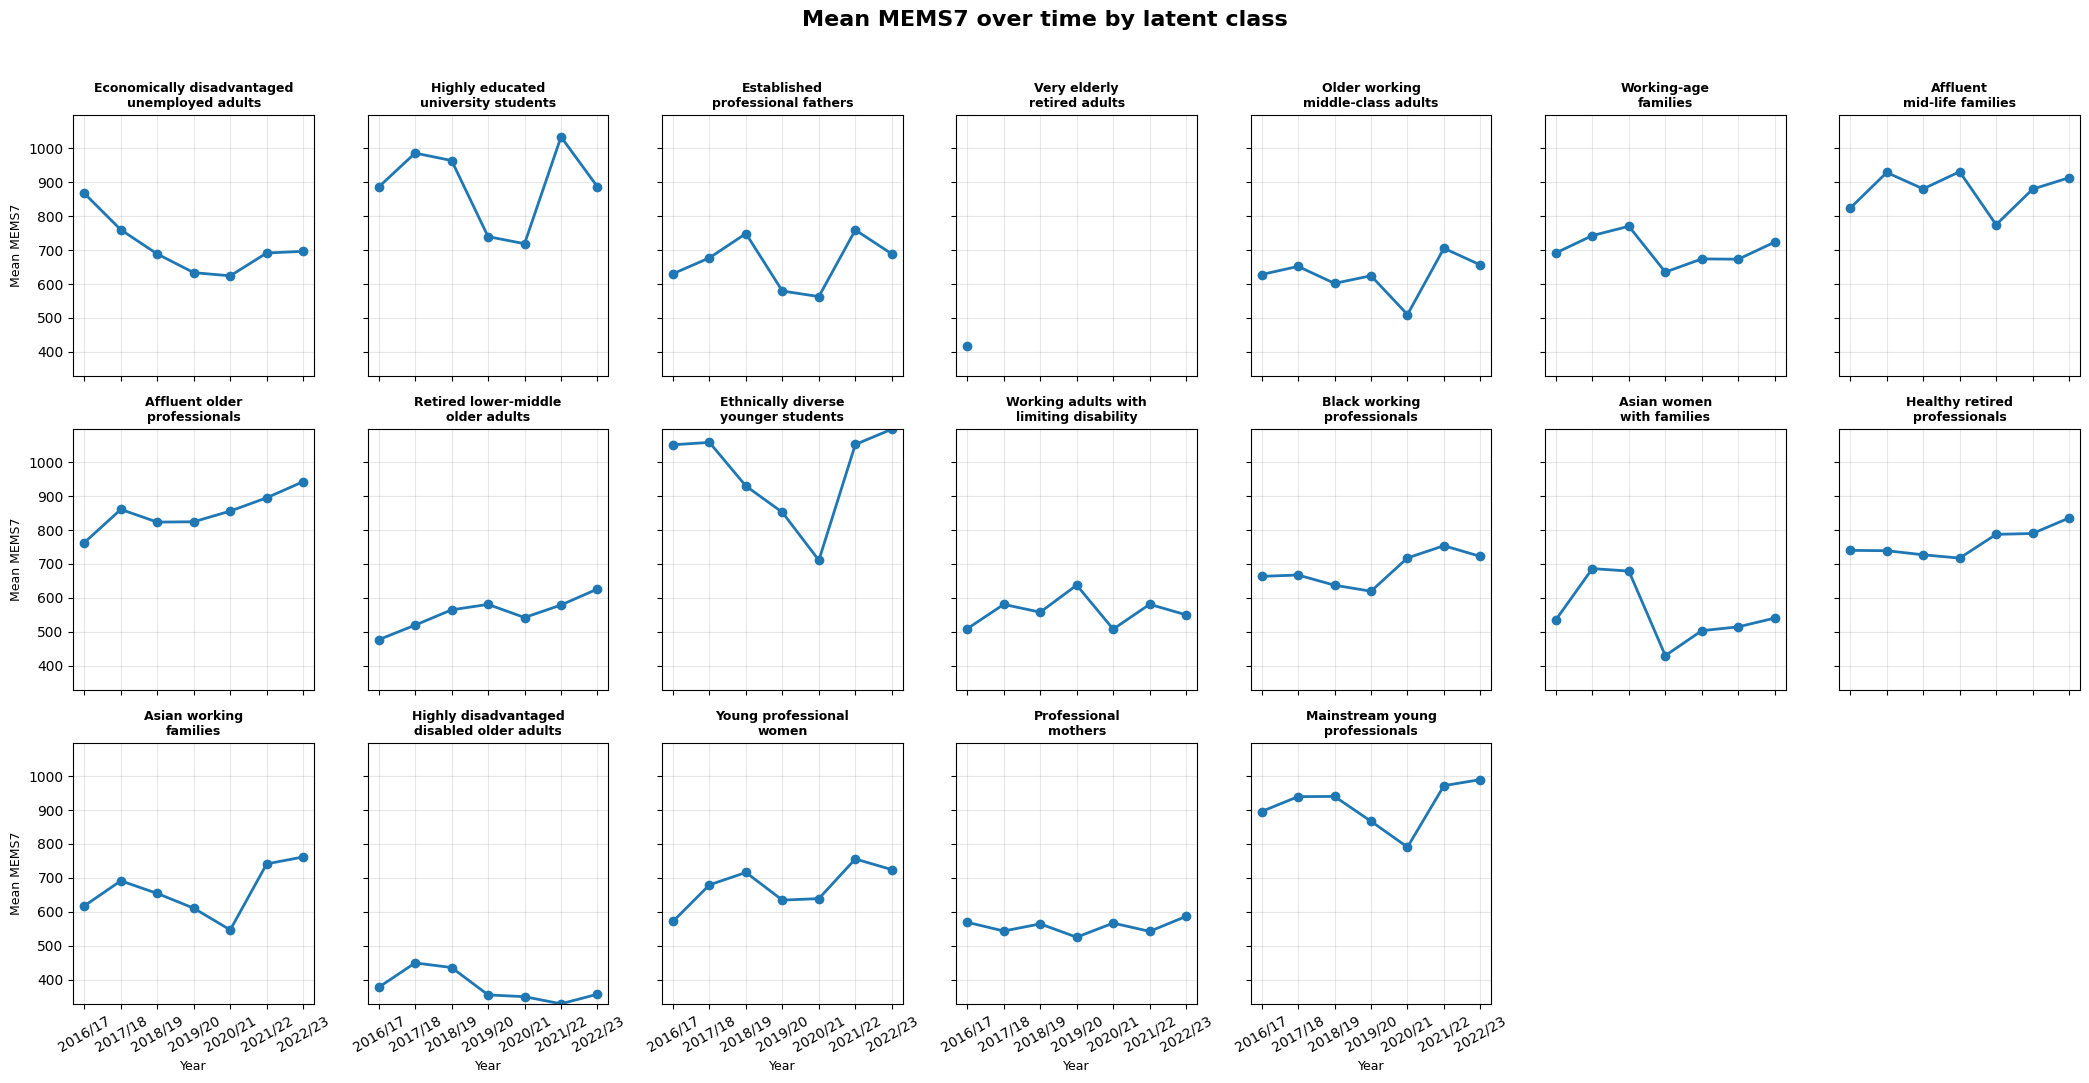

In [99]:
fig, axes = plt.subplots(3, 7, figsize=(21, 11), sharex=True, sharey=True)

axes = axes.flatten()

years = sorted(mems_summary["year"].unique())

ymin = mems_summary["Mean_MEMS7"].min()
ymax = mems_summary["Mean_MEMS7"].max()

for cls in range(n_classes):

    ax = axes[cls]

    tmp = mems_summary[mems_summary["Class"] == cls]

    tmp = tmp.sort_values("year")
    
    ax.plot(tmp["year"], tmp["Mean_MEMS7"], marker="o", linewidth=2)

    ax.set_xticks(years)

    ax.set_title(class_names[cls], fontsize=9, fontweight="bold")

    ax.grid(alpha=0.3)

    ax.set_ylim(ymin, ymax)

for ax in axes[n_classes:]:
        ax.axis("off")

for ax in axes[-7:]:
        ax.set_xlabel("Year", fontsize=9)
        ax.tick_params(axis="x", rotation=30)

for ax in axes[::7]:
        ax.set_ylabel("Mean MEMS7", fontsize=9)

fig.suptitle("Mean MEMS7 over time by latent class", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96]) # type: ignore
plt.show()